<a href="https://colab.research.google.com/github/kcoding400-life/Assignment3-for-IN26011064/blob/main/Assignment3_for_IN26011064.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name: Kushagra Raghuvanshi

Registration Number: 23BSA10072

Application Number: IN26011064

Batch Number: 2B

Topic
Salary Prediction using Polynomial Regression

Dataset
Position Salaries Dataset
Kaggle Link:
https://www.kaggle.com/datasets/akram24/position-salaries

Problem Statement
A company wants to estimate the salary of employees based on their position level. Since the relationship between position
level and salary is non-linear, develop a Polynomial Regression
model to predict employee salaries.

In [3]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Position_Salaries.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "akram24/position-salaries",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

Using Colab cache for faster access to the 'position-salaries' dataset.
First 5 records:             Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000


Task 1: Data Understanding

1. Load the dataset using Pandas.
2. Display the first five records.
3. Identify:
o Input Feature
o Target Variable
4. Display the dataset information and summary statistics.

In [10]:
print("First 5 records:")
print(df.head())

print("\nColumns in dataset:", df.columns.tolist())

print("\nInput Feature: Level")
print("Target Variable: Salary")
print("(Position is a text label duplicating Level, so it's excluded from modeling)")

print(df.dtypes)

print("\nDataset Info:")
df.info()

print("\nSummary Statistics:")
print(df.describe())

First 5 records:
            Position  Level  Salary
0   Business Analyst      1   45000
1  Junior Consultant      2   50000
2  Senior Consultant      3   60000
3            Manager      4   80000
4    Country Manager      5  110000

Columns in dataset: ['Position', 'Level', 'Salary']

Input Feature: Level
Target Variable: Salary
(Position is a text label duplicating Level, so it's excluded from modeling)
Position    object
Level        int64
Salary       int64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes

Summary Statistics:
          Level          Salary
count  10.00000       10.000000
mean    5.50000   249500.000000
std     3.02765   299373.883668
min     1.

Task 2: Data Preprocessing

Perform the following:
1. Check for missing values.
2. Select the appropriate feature(s) and target variable.
3. Split the dataset into 80% training and 20% testing.

In [5]:
from sklearn.model_selection import train_test_split

print("Missing values per column:")
print(df.isnull().sum())

X = df[['Level']].values
y = df['Salary'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Missing values per column:
Position    0
Level       0
Salary      0
dtype: int64

Training samples: 8
Testing samples: 2


Task 3: Model Development

1. Transform the input feature using Polynomial Features
(Degree = 3).
2. Train a Polynomial Regression model.
3. Predict salaries for the test dataset.

In [6]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly_reg = PolynomialFeatures(degree=3)
X_train_poly = poly_reg.fit_transform(X_train)
X_test_poly = poly_reg.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_poly, y_train)

y_pred = lin_reg.predict(X_test_poly)

print("Predicted salaries:", y_pred)
print("Actual salaries:   ", y_test)

Predicted salaries: [606335.60051157  84934.89129171]
Actual salaries:    [500000  50000]


Task 4: Model Evaluation

Evaluate the model using:
1. Mean Absolute Error (MAE)
2. Mean Squared Error (MSE)
3. R2 Score

Also create:
1. Scatter plot of the original data
2. Polynomial Regression Curve

MAE: 70635.25
MSE: 6263853282.86
R2 Score: 0.8763


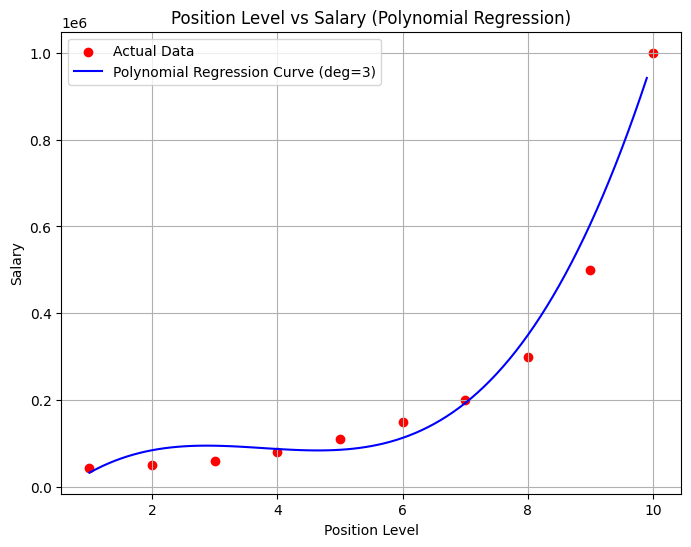

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.4f}")

X_grid = np.arange(X.min(), X.max(), 0.1).reshape(-1, 1)
X_grid_poly = poly_reg.transform(X_grid)
y_grid_pred = lin_reg.predict(X_grid_poly)

plt.figure(figsize=(8,6))
plt.scatter(X, y, color='red', label='Actual Data')
plt.plot(X_grid, y_grid_pred, color='blue', label='Polynomial Regression Curve (deg=3)')
plt.title('Position Level vs Salary (Polynomial Regression)')
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

## Model Performance Observations

1.  **Strong Explanatory Power**: The R2 Score of `0.8763` suggests that the polynomial regression model (with degree 3) explains a high percentage of the variance in salary, indicating a good overall fit to the data's trend.
2.  **Noticeable Prediction Errors**: Despite the high R2 score, the Mean Absolute Error (MAE) of approximately `$70,635` indicates that the model's predictions can still deviate significantly from the actual salaries for individual data points. This is further highlighted by the large Mean Squared Error (MSE).
3.  **Effective Capture of Non-Linearity**: Visually, the polynomial regression curve effectively captures the non-linear relationship between 'Position Level' and 'Salary', following the general upward trend of the data points. While it doesn't pass through every single point perfectly, it provides a reasonable approximation of the underlying pattern.